In [52]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader

import pytorch_lightning as pl

from torchmetrics.classification import BinaryAUROC

from datetime import datetime
# from xaikd.bases import PRCAReconGreedy, PRCASignAlignGreedy, PRCASignAlignGreedyV2
from tqdm.notebook import tqdm

from numpy import typing as npt

In [2]:
WITH_LAST_LAYER_BIAS = False

In [3]:
# Build Dataset
def build_task_targets():
    bin_rep1 = np.arange(8) % 2
    bin_rep2 = (np.arange(8) //2) % 2
    bin_rep3 = (np.arange(8) // 4) % 2
    
    y_t1 = np.logical_xor(bin_rep1, bin_rep2).astype(int)
    y_t2 = np.logical_xor(bin_rep1, bin_rep3).astype(int)
    y_t3 = np.logical_xor(bin_rep2, bin_rep3).astype(int)
    
    y = np.stack([y_t1, y_t2, y_t3]).T
    
    df = pd.DataFrame(
        dict(
            x1 = bin_rep1,
            x2 = bin_rep2,
            x3 = bin_rep3,
            x1_xor_x2 = y_t1,
            x1_xor_x3 = y_t2,
            x2_xor_x3 = y_t3
        )
    )
    return df, y

df, arr_task_targets = build_task_targets()
df

,x1,x2,x3,x1_xor_x2,x1_xor_x3,x2_xor_x3
0,0,0,0,0,0,0
1,1,0,0,1,1,0
2,0,1,0,1,0,1
3,1,1,0,0,1,1
4,0,0,1,0,1,1
5,1,0,1,1,0,1
6,0,1,1,1,1,0
7,1,1,1,0,0,0


In [4]:
def generate_dataset(num_per_groups=200, seed=1):
    rng = np.random.default_rng(seed=1)
    
    df, arr_task_targets = build_task_targets()
    
    arr_xs = []
    arr_ys = []
    
    arr_centers = 2*df[["x1", "x2", "x3"]].values - 1
    
    assert arr_centers.shape[0] == 8
    
    for cix in range(8):
        center = arr_centers[cix]
        group_x =  rng.normal(scale=0.5, size=(num_per_groups, 3)) + center
        arr_xs.append(group_x)
        
        
        code = np.array(list(np.binary_repr(2, width=3))).astype(int)
    
        ys = np.tile(arr_task_targets[cix], num_per_groups).reshape((num_per_groups, 3))
        arr_ys.append(ys)
        
    X = np.vstack(arr_xs)
    y = np.vstack(arr_ys)
    
    assert X.shape[0] == y.shape[0] == num_per_groups * 8 
    
    num_datapoints = num_per_groups * 8 
    
    return train_test_split(X, y, test_size=0.5, random_state=seed)

X_train, X_test, y_train, y_test = generate_dataset() 

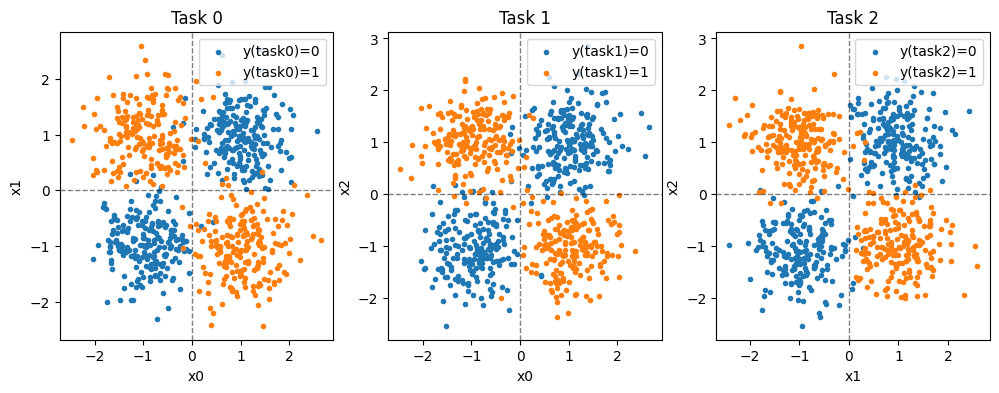

In [5]:
def viz(X, y):
    
    plt.figure(figsize=(3*4, 4))
    
    arr_coords = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]
    
    for tidx in range(3):
        plt.subplot(1, 3, tidx + 1)
        plt.title(f"Task {tidx}")
        
        coord1, coord2 = arr_coords[tidx]
        for ans in [0, 1]:

            selected = y[:, tidx] == ans

            plt.scatter(
                X[selected, coord1], X[selected, coord2],
                marker=".",
                label=f"y(task{tidx})={ans}"
            )
        plt.axhline(0, ls="--", lw=1, color="k", alpha=0.5)
        plt.axvline(0, ls="--", lw=1, color="k", alpha=0.5)
        plt.legend()
        plt.xlabel(f"x{coord1}")
        plt.ylabel(f"x{coord2}")
        
viz(X_train, y_train)

# Construct Model and Train

In [6]:
class MLP(nn.Module):
    def __init__(self, num_tasks=3):
        super().__init__()
        
        d = 128
        # d = 2
        
        self.lin1 = nn.Linear(3, d)
        self.act1 = nn.ReLU()
        self.lin2 = nn.Linear(d, num_tasks, bias=WITH_LAST_LAYER_BIAS)
    def forward(self, x):
        x = self.act1(self.lin1(x))
        x = self.lin2(x)
        
        out = [
            x[:, 0],
            x[:, 1],
            x[:, 2],
        ]
        
        return out
    def __str__(self):
        d, _ = self.lin1.weight.shape
        return f"MLP(d={d}, last_layer_bias={WITH_LAST_LAYER_BIAS})"
def ano():
    
    out = MLP()(torch.randn(10, 3))
    
    print(f"santity check: {MLP()} callable")
ano()

santity check: MLP(d=128, last_layer_bias=False) callable


In [7]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.SGD(
            self.parameters(), lr=self.lr, momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(3):
            y_task = y[:, tidx]
            logits_task = arr_logits[tidx]
            loss += (1/3)*F.binary_cross_entropy_with_logits(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):

        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()


In [10]:
pl.seed_everything(1)

dl_train = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train).float(),
        torch.from_numpy(y_train).float()
    ),
    batch_size=64,
    shuffle=True,
)

dl_train_noshuffle = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train).float(),
        torch.from_numpy(y_train).float()
    ),
    batch_size=64,
    shuffle=False,
)

dl_test = DataLoader(
    TensorDataset(
        torch.from_numpy(X_test).float(),
        torch.from_numpy(y_test).float()
    ),
    batch_size=64,
    shuffle=True,
)

model  = MLP()

trainer = pl.Trainer(
    max_epochs=500,
    default_root_dir="/tmp",
    log_every_n_steps=1000
)

trainer.fit(ModelWrapper(model), dl_train, dl_test)

[rank: 0] Global seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Missing logger folder: /tmp/lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type | Params
---------------------------------
0 | encoder | MLP  | 896   
---------------------------------
896       Trainable params
0         Non-trainable params
896       Total params
0.004     Total estimated model params size (MB)
/usr/local/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:430: PossibleUserWar

Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


In [11]:
def estimate_task_auroc(model, dl, task_id):
    metric_auroc = BinaryAUROC()

    for x, y in dl:
        task_logit = model(x)[task_id]
        task_target = y[:, task_id]
        metric_auroc.update(task_logit, task_target)

    auroc = float(metric_auroc.compute())
    auroc = 1-auroc if auroc < 0.5 else auroc
    return auroc

def compute_aurocs():
    
    stats = dict()
    
    for tidx in range(3):
        
        for label, dl in [
            ("train", dl_train),
            ("test", dl_test)
        ]:            
            stats[f"auroc_task_{tidx}_{label}"] = estimate_task_auroc(model, dl, tidx)
    
    return stats

ref_stats = compute_aurocs()
ref_stats

{'auroc_task_0_train': 0.9920439720153809,
 'auroc_task_0_test': 0.9897671937942505,
 'auroc_task_1_train': 0.9867480397224426,
 'auroc_task_1_test': 0.9769731163978577,
 'auroc_task_2_train': 0.9896681904792786,
 'auroc_task_2_test': 0.9840741157531738}

# Extract Grad

In [44]:

def grad_hook(mod, inp, outp):
    outp.retain_grad()
    setattr(mod, "__outp", outp)

class LogOddWinningTauZero:
    def __call__(self, logit):
        sign = torch.sign(logit).detach()
        return (sign * logit)

OUTPUT_QUANTITY = LogOddWinningTauZero()

def extract_act_grad(model, dl, task_id):
    module_name = "act1"
    arr_act = []
    arr_ctx = []
    arr_task_logit = []
    module = getattr(model, module_name)
    for x, y in dl:
                
        try:

            x.requires_grad_()
            hook = module.register_forward_hook(grad_hook)

            arr_logits = model(x)
            task_logit = arr_logits[task_id]

            OUTPUT_QUANTITY(task_logit).sum().backward()
            
            
            
            act = getattr(module, "__outp")
            ctx = act.grad.detach().numpy()
            act = act.detach().numpy()
            arr_act.append(act)
            arr_ctx.append(ctx)
            arr_task_logit.append(task_logit.detach())
            
            
        finally:
            hook.remove()
    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)
    arr_task_logit = np.concatenate(arr_task_logit)
    
    return arr_task_logit, arr_act, arr_ctx

extract_act_grad(model, dl_train_noshuffle, 0)

(array([-3.14139038e-01, -2.16438949e-01,  9.34177160e-01, -2.97903717e-01,
        -5.50396085e-01,  9.58618164e-01,  3.91061753e-01, -3.41266841e-01,
         2.45866001e-01, -1.51170254e-01,  6.49766743e-01, -1.52963385e-01,
         2.83719242e-01, -6.37805998e-01,  3.09013784e-01, -7.78755367e-01,
         1.11045527e+00, -5.92804015e-01,  8.50511312e-01,  1.47441819e-01,
         1.63002938e-01, -9.27959621e-01, -6.94917083e-01, -2.21402794e-01,
        -1.01230872e+00,  4.20448035e-01,  2.02514499e-01,  2.55065888e-01,
        -3.59195173e-01, -1.46235240e+00, -5.74694216e-01,  3.46973240e-01,
         8.18046510e-01,  9.39101875e-02, -5.95985651e-01, -8.83511662e-01,
        -1.37511921e+00, -7.30736792e-01,  4.62679774e-01,  4.71479148e-01,
        -3.93103063e-01,  3.96985918e-01,  7.64709413e-01,  3.31565529e-01,
         7.49924779e-01, -1.50744200e-01,  2.17872068e-01, -9.50713098e-01,
         2.20848080e-02,  8.16237092e-01,  1.38209090e-01, -6.38603032e-01,
         6.2

In [47]:
def sanity_check():
    _, arr_act, _ = extract_act_grad(model, dl_train_noshuffle, 0)
    
    for tidx in [1, 2]:
        _, arr_act_other, _ = extract_act_grad(model, dl_train_noshuffle, tidx)
        np.testing.assert_allclose(
            arr_act_other,
            arr_act
        )
        print(f"arr_act(T0) == arr_act(T{tidx})")
    print("all passed!")
sanity_check()

arr_act(T0) == arr_act(T1)
arr_act(T0) == arr_act(T2)
all passed!


# Visualizing Weighting

In [22]:
from scipy.stats import norm as norm_gaussian

In [23]:
norm_gaussian.pdf(np.array([1]), 0, 1)

array([0.24197072])

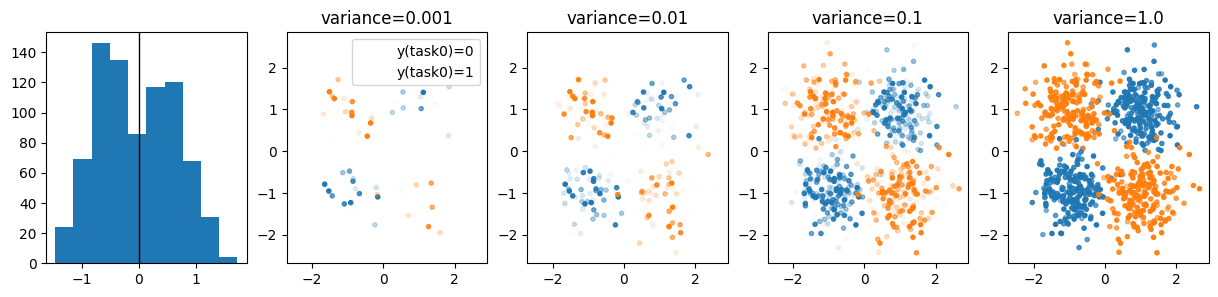

In [42]:
def ano():
    task_id = 0

    X, y = X_train, y_train
    # TODO: this should be define globally
    arr_coords = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]

    
    coord1, coord2 = arr_coords[task_id]

    arr_variances = [0.001, 0.01, 0.1, 1.0]

    ncols = len(arr_variances) + 1
    plt.figure(figsize=(3*ncols, 3))

    for vix, var in enumerate(arr_variances):
        
        arr_task_logits = model(torch.from_numpy(X).float())[task_id].detach().numpy()
        
        if vix == 0:
            plt.subplot(1, ncols, vix + 1)
            plt.hist(arr_task_logits)
            plt.axvline(0, ls="-", lw=1, color="k")
            
        # print(arr_task_logits.shape)
        assert arr_task_logits.shape == (X.shape[0],)

        plt.subplot(1, ncols, vix + 2)
        plt.title(f"variance={var}")

        
        std = var ** 0.5
        arr_weighs = norm_gaussian.pdf(arr_task_logits, loc=0, scale=std)
        
        assert (arr_weighs >= 0).sum()
        arr_weighs = arr_weighs / np.sum(arr_weighs)
        # np.testing.assert_allclose(arr_weighs.sum(), 1.0)
        
        # return arr_weighs
        for ans in [0, 1]:
            selected = y[:, task_id] == ans
            plt.scatter(
                X[selected, coord1], 
                X[selected, coord2],
                alpha=arr_weighs / np.max(arr_weighs),
                marker=".",
                label=f"y(task{task_id})={ans}"
            )
        if vix == 0:
            plt.legend()
ano()    

# Spectrum of PRCA-Sortabs and PRCA-Sign-Align-SortAbs

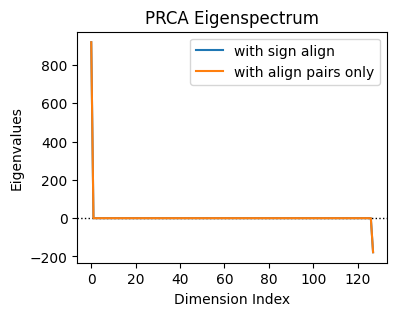

In [50]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs



def get_prca_spectrum(A, C):

    cov = A.T @ C + C.T @ A

    return np.linalg.eigvalsh(cov)[::-1]



def ano():
    _, arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id=1)
    
    arr_rel = (arr_act * arr_ctx).sum(axis=1, keepdims=True)
    arr_ctx_signed = (arr_rel >= 0) * arr_ctx - (arr_rel < 0) * arr_ctx
    arr_ctx_pos_pair = (arr_rel >= 0) * arr_ctx

    eigvals_prca = get_prca_spectrum(arr_act, arr_ctx)
    
    eigvals_prca_sign_align = get_prca_spectrum(arr_act, arr_ctx_signed)
    eigvals_prca_pos_pair = get_prca_spectrum(arr_act, arr_ctx_pos_pair)
    
    
    plt.figure(figsize=(4, 3))
    plt.title("PRCA Eigenspectrum")
    plt.axhline(0, ls=":", lw=1, color="k")
    # plt.plot(eigvals_prca, label="without sign align (current)")
    plt.plot(eigvals_prca_sign_align, label="with sign align")
    plt.plot(eigvals_prca_pos_pair, label="with align pairs only")

    plt.ylabel("Eigenvalues")
    plt.xlabel("Dimension Index")
    plt.legend()
ano()

# Basis Consturction

In [72]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs, sort_func(eigvals)

class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_logit, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        cov = arr_act.T @ arr_act / N
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_logit, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        
        cov = arr_ctx.T @ arr_ctx / N
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
        
class PRCASortAbs(BasisInterface):
    def __init__(self, arr_logit, arr_act, arr_ctx, layer=None, task_id=None):

        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

        
class PRCA(BasisInterface):
    def __init__(self, arr_logit, arr_act, arr_ctx, layer=None, task_id=None):

        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]



class PRCAPosDef(BasisInterface):
    def __init__(self, arr_logit, arr_act, arr_ctx, layer=None, task_id=None):

        cov_a = arr_act.T @ arr_act
        cov_c = arr_ctx.T @ arr_ctx
        
        cov_ac = arr_act.T @ arr_ctx 
        cov_acca = cov_ac + cov_ac.T
        
        cov = (1/np.sqrt(np.trace(cov_a) * np.trace(cov_c)))*cov_acca \
            + (2/np.trace(cov_a)) * cov_a \
            + (2/np.trace(cov_c)) * cov_c

        
        self.U, self.eigvals = _solve_eigvecs(cov)

        assert (self.eigvals >= 0).all()
    
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCAPosDefWithWeight(BasisInterface):
    def __init__(self, arr_logit, arr_act, arr_ctx, variance: float, layer=None, task_id=None):

        weight = norm_gaussian.pdf(
            arr_logit, loc=0, 
            scale=variance ** 0.5
        )
        arr_ctx = arr_ctx * weight[:, np.newaxis]
        
        cov_a = arr_act.T @ arr_act
        cov_c = arr_ctx.T @ arr_ctx
        
        cov_ac = arr_act.T @ arr_ctx 
        cov_acca = cov_ac + cov_ac.T
        
        cov = (1/np.sqrt(np.trace(cov_a) * np.trace(cov_c)))*cov_acca \
            + (2/np.trace(cov_a)) * cov_a \
            + (2/np.trace(cov_c)) * cov_c

        
        self.U, self.eigvals = _solve_eigvecs(cov)

        assert (self.eigvals >= 0).all()
    
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCAPosDefWithWeightVar10000(PRCAPosDefWithWeight):
    def __init__(self, variance=10000, **kwargs):
        super().__init__(**kwargs, variance=variance)

class PRCAPosDefWithWeightVar10(PRCAPosDefWithWeight):
    def __init__(self, variance=10, **kwargs):
        super().__init__(**kwargs, variance=variance)

class PRCAPosDefWithWeightVar1(PRCAPosDefWithWeight):
    def __init__(self, variance=1.0, **kwargs):
        super().__init__(**kwargs, variance=variance)

class PRCAPosDefWithWeightVar0_1(PRCAPosDefWithWeight):
    def __init__(self, variance=0.1, **kwargs):
        super().__init__(**kwargs, variance=variance)
class PRCAPosDefWithWeightVar0_01(PRCAPosDefWithWeight):
    def __init__(self, variance=0.01, **kwargs):
        super().__init__(**kwargs, variance=variance)

class PRCAPosDefWithWeightVar0_001(PRCAPosDefWithWeight):
    def __init__(self, variance=0.001, **kwargs):
        super().__init__(**kwargs, variance=variance)

# Estimate Staistica

In [73]:
from xaikd.bases import pcalookahead

        
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return outp @ (Uk@Uk.T)
    return fh

def compute_task_auroc_at_k(
    model, task_id, arr_ks,
    arr_basis_classes=[PCA, PRCASortAbs]
):
    arr_logit, arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    arr_stat_rows = []
    
    module = getattr(model, "act1")
    
    for basis_class in arr_basis_classes:
        basis_name = basis_class.__name__
        
        basis = basis_class(arr_logit=arr_logit, arr_act=arr_act, arr_ctx=arr_ctx)
        
        for k in arr_ks:
            Uk = basis.get_Uk(k=k)
            Uk = torch.from_numpy(Uk).float()
            row = dict(
                task_id=task_id, 
                k=k,   
                basis_name=basis_name,
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    ("train", dl_train_noshuffle),
                    ("test", dl_test)
                ]:
                    row[f"auroc_{label}"] = estimate_task_auroc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
    df = pd.DataFrame(arr_stat_rows).sort_values(by=["k", f"auroc_test"], ascending=[True, False])
    
    return df

compute_task_auroc_at_k(
    model, 
    task_id=0, 
    arr_ks=np.arange(1, 3).tolist() + [64],
    arr_basis_classes=[
        # PCA,
        # GradPCA,
        # PRCASortAbs,
        PRCAPosDef,

        # PRCAPosDefWithWeightVar0_001,
        PRCAPosDefWithWeightVar0_01,
        PRCAPosDefWithWeightVar0_1,
        PRCAPosDefWithWeightVar1,
        PRCAPosDefWithWeightVar10,
        PRCAPosDefWithWeightVar10000
    ]
)

,task_id,k,basis_name,auroc_train,auroc_test
3,0,1,PRCAPosDefWithWeightVar0_01,0.990324,0.989223
6,0,1,PRCAPosDefWithWeightVar0_1,0.990093,0.989129
9,0,1,PRCAPosDefWithWeightVar1,0.988310,0.988491
12,0,1,PRCAPosDefWithWeightVar10,0.987878,0.988291
0,0,1,PRCAPosDef,0.987803,0.988254
15,0,1,PRCAPosDefWithWeightVar10000,0.987803,0.988254
4,0,2,PRCAPosDefWithWeightVar0_01,0.990474,0.989211
7,0,2,PRCAPosDefWithWeightVar0_1,0.990368,0.989142
10,0,2,PRCAPosDefWithWeightVar1,0.989179,0.988566
13,0,2,PRCAPosDefWithWeightVar10,0.988835,0.988379


# Accuracy Curves

  0%|          | 0/3 [00:00<?, ?it/s]

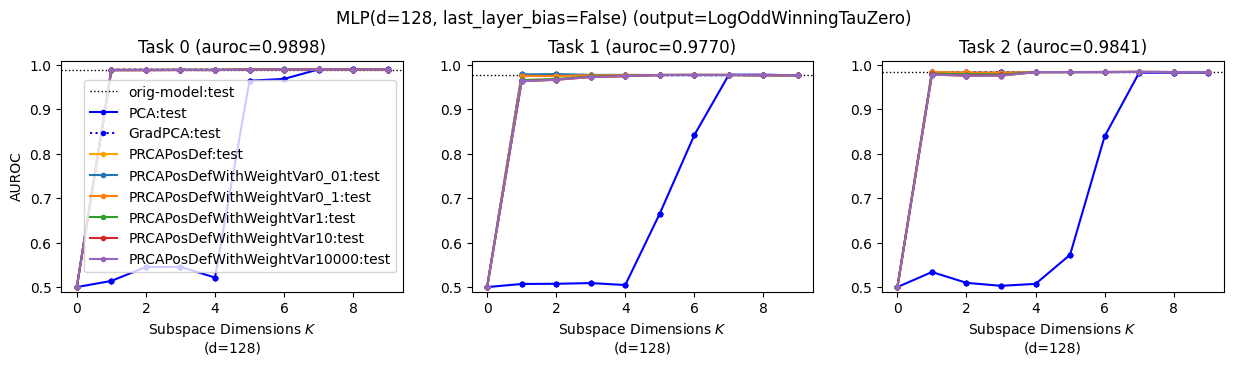

In [81]:
def viz(arr_basis_classes=[PCA], max_k=10):

    def ls_color(basis_class):
        return {
            PCA: ("-", "blue"),
            GradPCA: (":", "blue"),
            PRCA: (":", "red"),
            PRCASortAbs: ("-", "red"),
            PRCAPosDef: ("-", "orange"),
        }.get(basis_class, (None, None))
    arr_task_ids = np.arange(3)
    plt.figure(figsize=(5*3, 3))
    
    d = model.lin1.weight.shape[0]

    arr_ks = np.linspace(0, max_k).astype(int).tolist() + [d]
    
    plt.suptitle(f"{model} (output={OUTPUT_QUANTITY.__class__.__name__})", y=1.05)
    
    for task_id in tqdm(arr_task_ids):
        plt.subplot(1, 3, task_id+1)
        plt.title(f"Task {task_id}")
        df = compute_task_auroc_at_k(model, task_id=task_id, arr_ks=arr_ks, arr_basis_classes=arr_basis_classes)
        
        for bix, basis_class in enumerate(arr_basis_classes):
            basis_name = basis_class.__name__
            
            _df = df[
                (df.basis_name == basis_name) 
            ]
            
            if bix == 0:
                
                ref = ref_stats[f"auroc_task_{task_id}_test"]
                plt.title(f"Task {task_id} (auroc={ref:.4f})")

                plt.axhline(
                    ref,
                    ls=":",
                    lw=1,
                    color="k",
                    label="orig-model:test"
                )
            ls, color = ls_color(basis_class)
            selected = _df.k < max_k
            for label in ["test"]:
                plt.plot(
                    _df.k[selected],
                    _df[f"auroc_{label}"][selected],
                    color=color,
                    ls=ls,
                    marker=".",
                    label=f"{basis_name}:{label}"
                )
        plt.ylim([0.5-0.01, 1.01])
        if task_id == 0:
            plt.legend()
            plt.ylabel("AUROC")
        plt.xlabel(f"Subspace Dimensions $K$\n(d={d})")
viz(
    arr_basis_classes=[
        PCA,
        GradPCA,
        # PRCASortAbs,
        PRCAPosDef,
        PRCAPosDefWithWeightVar0_01,
        PRCAPosDefWithWeightVar0_1,
        PRCAPosDefWithWeightVar1,
        PRCAPosDefWithWeightVar10,
        PRCAPosDefWithWeightVar10000
    ]
)

In [ ]:
raise

# Decision Boundary

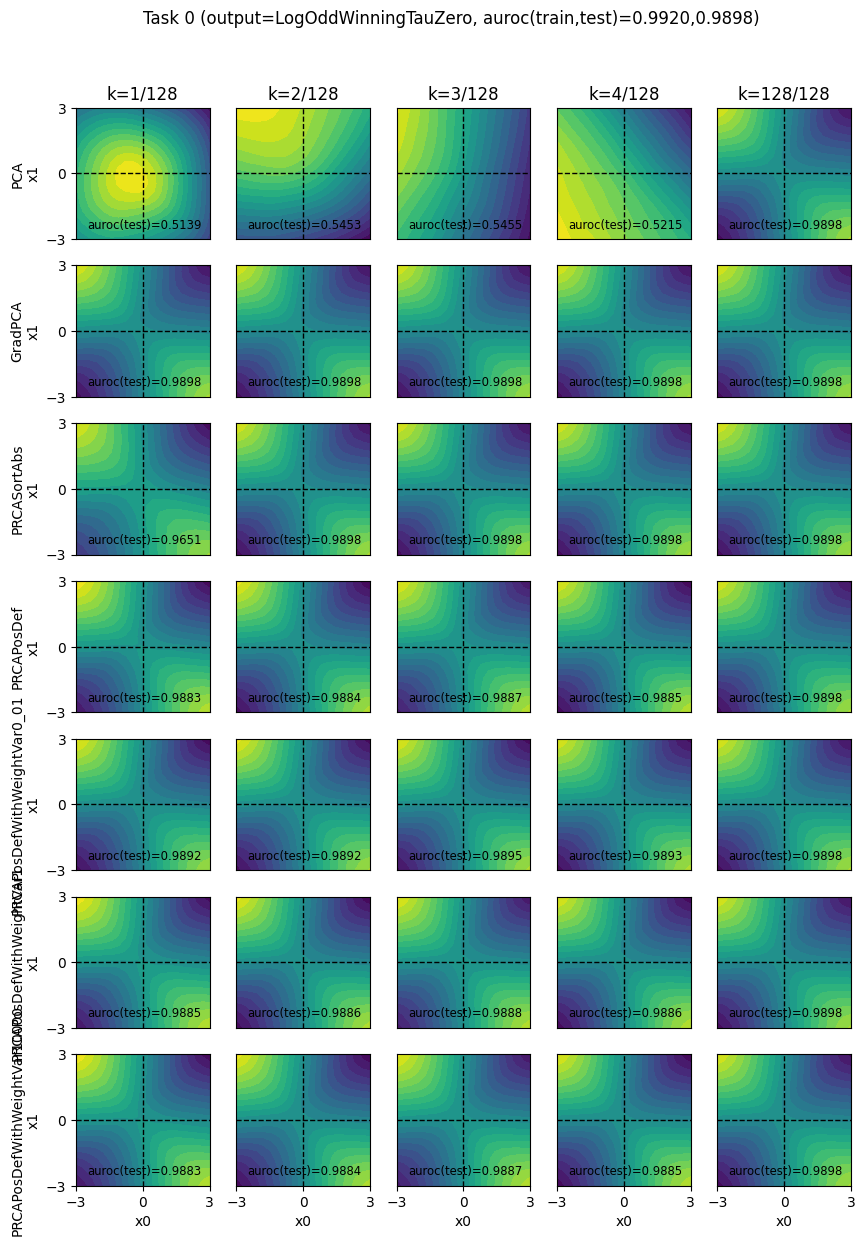

In [80]:
def decision_boundary(task_id, arr_ks=[1, 2, 3, 4]):

    arr_basis_classes = [
        PCA,
        GradPCA,
        PRCASortAbs,
        PRCAPosDef,
        PRCAPosDefWithWeightVar0_01,
        PRCAPosDefWithWeightVar1,
        PRCAPosDefWithWeightVar10000
    ]
        
    d = model.lin1.weight.shape[0]
    arr_ks = arr_ks + [d]
    
    nrows = len(arr_basis_classes)
    ncols = len(arr_ks)
    
    arr_coords = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]
    
    _xx = np.linspace(-3, 3, 20)
    module = getattr(model, "act1")
    plt.figure(figsize=(2*ncols, 2*nrows))
    
    auroc_train = ref_stats[f"auroc_task_{task_id}_train"]
    auroc_test = ref_stats[f"auroc_task_{task_id}_test"]
    plt.suptitle(
        f"Task {task_id} (output={OUTPUT_QUANTITY.__class__.__name__}, auroc(train,test)={auroc_train:.4f},{auroc_test:.4f})",
        y=0.95
    )
    
    arr_logit, arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    
    for bix, basis_class in enumerate(arr_basis_classes):
        basis = basis_class(arr_logit=arr_logit, arr_act=arr_act, arr_ctx=arr_ctx)
        
        basis_name = basis_class.__name__
        
        coord_1, coord_2 = arr_coords[task_id]

        X = np.zeros((400, 3))
        
        xx, yy = np.meshgrid(_xx, _xx)
        
        X[:, coord_1] = xx.reshape(-1)
        X[:, coord_2] = yy.reshape(-1)
        
        X = torch.from_numpy(X).float()
        for kix, k in enumerate(arr_ks):
            Uk = torch.from_numpy(basis.get_Uk(k=k)).float()
            plt.subplot(nrows, ncols, bix * ncols + kix + 1)
            if bix == 0:
                plt.title(f"k={k}/{d}")
            
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                task_logits = model(X)[task_id].detach().numpy()
                
                auroc = estimate_task_auroc(
                    model,
                    dl_test,
                    task_id=task_id
                )
            
            finally:
                hook.remove()
                     
            plt.contourf(
                X[:, coord_1].reshape((20, 20)),
                X[:, coord_2].reshape((20, 20)),
                task_logits.reshape((20, 20)),
                levels=20,
            )
            
            plt.text(
                -2.5, -2.5, 
                f"auroc(test)={auroc:.4f}", 
                fontsize="small",
            )
            
            plt.axhline(0, ls="--", lw=1, color="k")
            plt.axvline(0, ls="--", lw=1, color="k")
            
            if bix == nrows - 1:
                plt.xlabel(f"x{coord_1}")
                plt.xticks([-3, 0, 3])

            else:
                plt.xticks([])
            if kix == 0:
                plt.ylabel(f"{basis_name}\nx{coord_2}")
                plt.yticks([-3, 0, 3])
            else:
                plt.yticks([])

decision_boundary(task_id=0)

In [ ]:
for task_id in range(3):
    decision_boundary(task_id=task_id)
    plt.show()

In [ ]:
print(f"Finished at {datetime.now()}")